In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss
)

from sklearn.ensemble import GradientBoostingClassifier,HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


## 2. Load dữ liệu và khám phá


2.1 Load dữ liệu

In [2]:
feature_name = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income"
]
df_data = pd.read_csv(r"D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-07-Gradient-Boosting\adult.data",header = None,
                      sep =r",\s*", names = feature_name,na_values = "?")

C:\Users\hieum\AppData\Local\Temp\ipykernel_5784\3767513987.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_data = pd.read_csv(r"D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-07-Gradient-Boosting\adult.data",header = None,


2.2 Khám phá dữ liệu

In [3]:
df_data.shape
df_data.info()
df_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


2.3 Xử lý dữ liệu rác

In [4]:
df_data.isnull().sum()
df_data = df_data.dropna()
df_data.isnull().sum()


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

2.4 Kiểm tra dấu cách thừa sau khi đọc dữ liệu

In [5]:
# Kiểm tra còn sót khoảng trắng thừa ở đầu/cuối các cột chuỗi hay không
str_cols = df_data.select_dtypes(include="object").columns
has_extra_space = {
    c: df_data[c].str.contains(r"^\s|\s$", regex=True).any()
    for c in str_cols
}
print("Còn khoảng trắng thừa:", any(has_extra_space.values()))

Còn khoảng trắng thừa: False


In [6]:
df_data = df_data.drop(['education_num','fnlwgt'],axis =1)
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital_status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital_gain    30162 non-null  int64 
 9   capital_loss    30162 non-null  int64 
 10  hours_per_week  30162 non-null  int64 
 11  native_country  30162 non-null  object
 12  income          30162 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


## 3 EDA 

In [7]:
# Tính tỷ lệ >50K theo education
edu_income = pd.crosstab(
    df_data["education"],
    df_data["income"],
    normalize="index"
) * 100

print(edu_income)

income             <=50K       >50K
education                          
10th           92.804878   7.195122
11th           94.370229   5.629771
12th           92.307692   7.692308
1st-4th        96.026490   3.973510
5th-6th        95.833333   4.166667
7th-8th        93.716338   6.283662
9th            94.505495   5.494505
Assoc-acdm     74.603175  25.396825
Assoc-voc      73.680184  26.319816
Bachelors      57.850912  42.149088
Doctorate      25.333333  74.666667
HS-grad        83.567073  16.432927
Masters        43.577136  56.422864
Preschool     100.000000   0.000000
Prof-school    25.092251  74.907749
Some-college   79.994010  20.005990


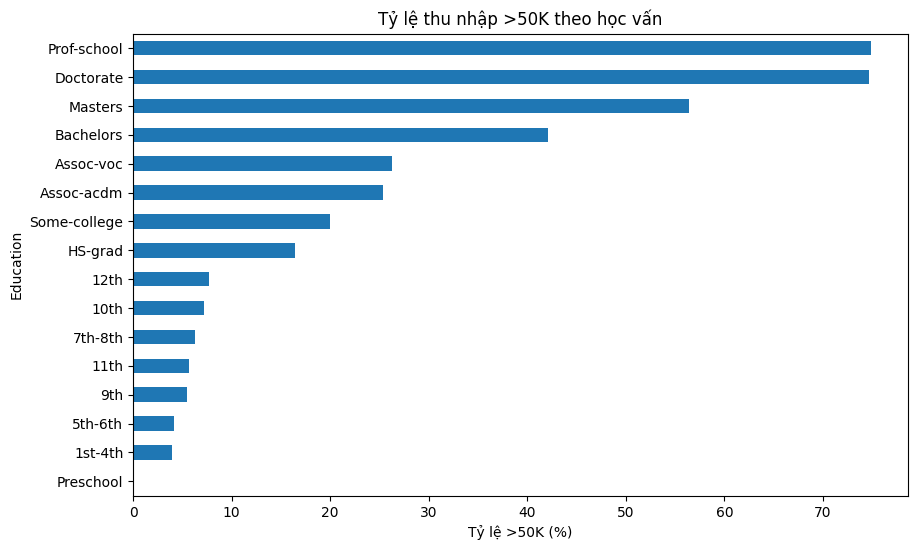

In [8]:
edu_income[">50K"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Tỷ lệ >50K (%)")
plt.ylabel("Education")
plt.title("Tỷ lệ thu nhập >50K theo học vấn")
plt.show()

In [9]:
bins = [0, 29, 39, 49, 59, float("inf")]
labels = ["<30", "30-39", "40-49", "50-59", ">=60"]

df_data["hours_group"] = pd.cut(
    df_data["hours_per_week"],
    bins=bins,
    labels=labels
)

In [10]:
hours_income = pd.crosstab(
    df_data["hours_group"],
    df_data["income"],
    normalize="index"
) * 100

print(hours_income)

income           <=50K       >50K
hours_group                      
<30          93.517973   6.482027
30-39        86.837349  13.162651
40-49        75.873660  24.126340
50-59        55.246253  44.753747
>=60         58.648759  41.351241


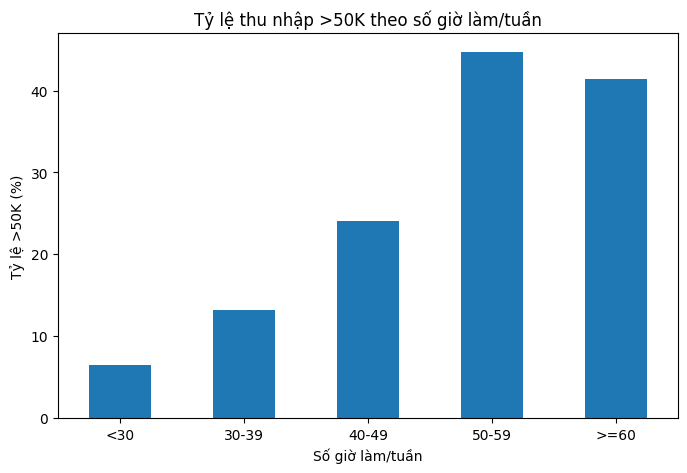

In [11]:
hours_income[">50K"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Số giờ làm/tuần")
plt.ylabel("Tỷ lệ >50K (%)")
plt.title("Tỷ lệ thu nhập >50K theo số giờ làm/tuần")
plt.xticks(rotation=0)
plt.show()

In [12]:
marital_income = pd.crosstab(
    df_data["marital_status"],
    df_data["income"],
    normalize="index"
) * 100

print(marital_income)

income                     <=50K       >50K
marital_status                             
Divorced               89.273849  10.726151
Married-AF-spouse      52.380952  47.619048
Married-civ-spouse     54.504088  45.495912
Married-spouse-absent  91.621622   8.378378
Never-married          95.167592   4.832408
Separated              92.971246   7.028754
Widowed                90.326481   9.673519


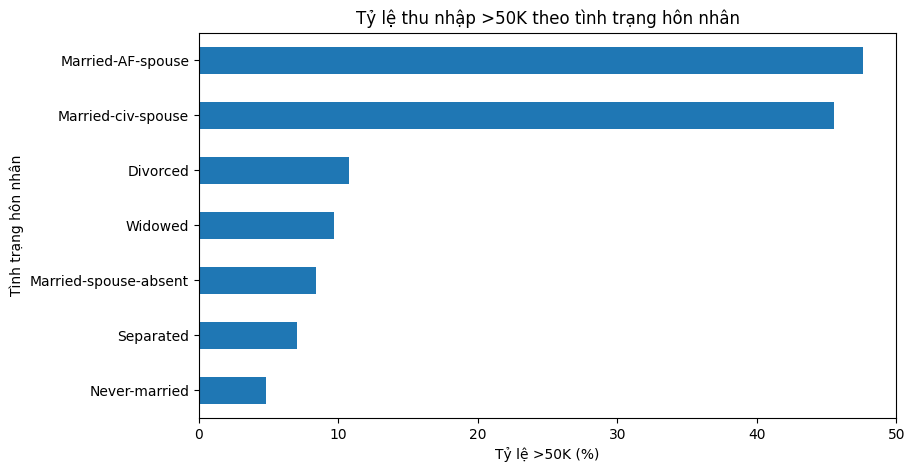

In [13]:
marital_income[">50K"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.xlabel("Tỷ lệ >50K (%)")
plt.ylabel("Tình trạng hôn nhân")
plt.title("Tỷ lệ thu nhập >50K theo tình trạng hôn nhân")
plt.show()

In [14]:
df_data["capital_gain"].describe()

count    30162.000000
mean      1092.007858
std       7406.346497
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_gain, dtype: float64

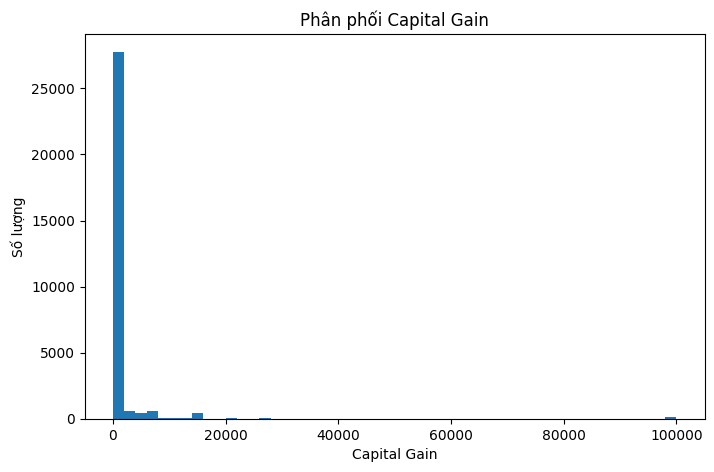

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_data["capital_gain"], bins=50)
plt.xlabel("Capital Gain")
plt.ylabel("Số lượng")
plt.title("Phân phối Capital Gain")
plt.show()

In [16]:
# Tỉ lệ capital_gain = 0 trong dữ liệu
zero_ratio = (df_data["capital_gain"] == 0).mean() * 100
print(f"Tỉ lệ capital_gain = 0: {zero_ratio:.1f}%")

Tỉ lệ capital_gain = 0: 91.6%


⚠️ Phân phối `capital_gain` lệch cực đoan (đa số bằng 0). Vì vậy trong `preprocessor` ở bước sau, `capital_gain` được **nhị phân hoá** (`> 0` → 1, ngược lại → 0) thay vì giữ nguyên giá trị liên tục hay lấy log (log không xử lý được vì có nhiều giá trị 0).

In [17]:
x = df_data.drop(['income'],axis = 1)
y = df_data['income']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify = y)


In [18]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, pos_label=">50K"))
    print("Recall   :", recall_score(y_test, y_pred, pos_label=">50K"))
    print("F1-score :", f1_score(y_test, y_pred, pos_label=">50K"))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [19]:
cat_cols = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]
num_cols = [
    "age",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(
             handle_unknown="ignore",
             sparse_output=False
         ),
         cat_cols),

        ("capital_gain",
         FunctionTransformer(lambda x: (x > 0).astype(int)),
         ["capital_gain"]),

        ("num",
         "passthrough",
         ["age", "capital_loss", "hours_per_week"])
    ]
)

pipeline_gbc_basic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

pipeline_gbc_basic.fit(x_train,y_train)
y_pred = pipeline_gbc_basic.predict(x_test)


In [20]:
dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(x_train, y_train)

dummy_pred = dummy.predict(x_test)

In [21]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(x_train, y_train)

dt_pred = dt_pipeline.predict(x_test)

In [22]:
evaluate_model("Dummy Classifier", y_test, dummy_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Gradient Boosting", y_test, y_pred)


===== Dummy Classifier =====
Accuracy : 0.7510359688380573
Precision: 0.0
Recall   : 0.0
F1-score : 0.0

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.75      1.00      0.86      4531
        >50K       0.00      0.00      0.00      1502

    accuracy                           0.75      6033
   macro avg       0.38      0.50      0.43      6033
weighted avg       0.56      0.75      0.64      6033


===== Decision Tree =====
Accuracy : 0.797778882811205
Precision: 0.5957880434782609
Recall   : 0.5838881491344874


c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

F1-score : 0.589778076664425

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.86      0.87      0.87      4531
        >50K       0.60      0.58      0.59      1502

    accuracy                           0.80      6033
   macro avg       0.73      0.73      0.73      6033
weighted avg       0.80      0.80      0.80      6033


===== Gradient Boosting =====
Accuracy : 0.8433615116857285
Precision: 0.7402933563416738
Recall   : 0.5712383488681758
F1-score : 0.644870349492672

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4531
        >50K       0.74      0.57      0.64      1502

    accuracy                           0.84      6033
   macro avg       0.80      0.75      0.77      6033
weighted avg       0.84      0.84      0.84      6033



In [23]:
# Lấy model Gradient Boosting
gbc = pipeline_gbc_basic.named_steps["model"]

# Biến đổi train/test bằng preprocessor đã fit
X_train_processed = pipeline_gbc_basic.named_steps["preprocessor"].transform(x_train)
X_test_processed = pipeline_gbc_basic.named_steps["preprocessor"].transform(x_test)

# Loss theo từng số cây
train_loss = []
val_loss = []

for train_score, val_score in zip(
    gbc.staged_decision_function(X_train_processed),
    gbc.staged_decision_function(X_test_processed)
):
    train_loss.append(
        log_loss(y_train, 1 / (1 + np.exp(-train_score.ravel())))
    )
    
    val_loss.append(
        log_loss(y_test, 1 / (1 + np.exp(-val_score.ravel())))
    )

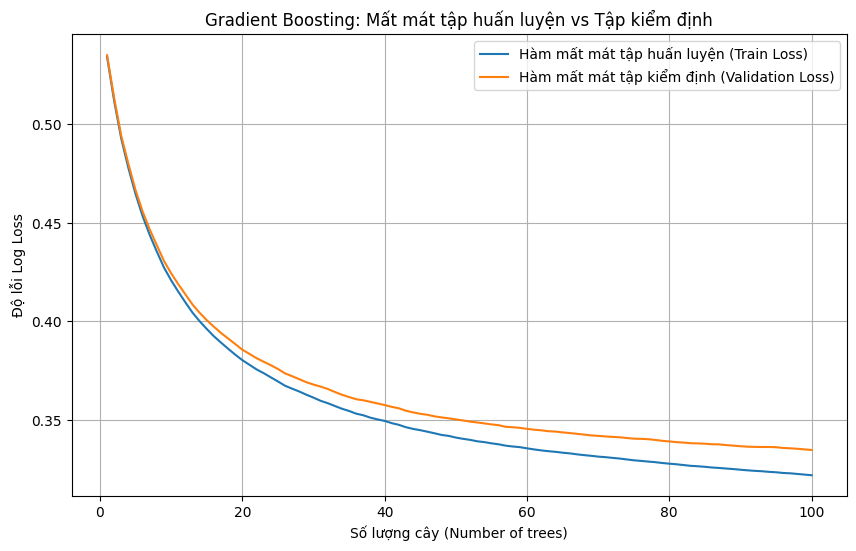

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_loss) + 1),
    train_loss,
    label="Hàm mất mát tập huấn luyện (Train Loss)"
)

plt.plot(
    range(1, len(val_loss) + 1),
    val_loss,
    label="Hàm mất mát tập kiểm định (Validation Loss)"
)

plt.xlabel("Số lượng cây (Number of trees)")
plt.ylabel("Độ lỗi Log Loss")
plt.title("Gradient Boosting: Mất mát tập huấn luyện vs Tập kiểm định")
plt.legend()
plt.grid()
plt.show()

In [25]:
from sklearn.metrics import make_scorer, f1_score
f1_scorer = make_scorer(f1_score, pos_label=">50K")

param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [50, 100, 200]
}
grid = GridSearchCV(
    pipeline_gbc_basic,
    param_grid=param_grid,
    cv=5,
    scoring=f1_scorer, 
    n_jobs=-1
)
grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'model__learning_rate': 0.1, 'model__n_estimators': 200}
Best CV score: 0.6670326190232818


In [26]:
results = pd.DataFrame(grid.cv_results_)

print(
    results[
        [
            "param_model__learning_rate",
            "param_model__n_estimators",
            "mean_test_score"
        ]
    ].sort_values("mean_test_score", ascending=False)
)

print(
    "Trong biểu đồ này chính là mối tương quan nghịch biến giữa "
    "Số lượng cây và Độ lỗi Log Loss khi số lượng cây được bổ sung tăng lên ($x ↑$),\n"
    "độ lỗi của mô hình trên cả tập huấn luyện và tập kiểm định sẽ giảm xuống ($y ↓$)."
)

   param_model__learning_rate  param_model__n_estimators  mean_test_score
8                        0.10                        200         0.667033
7                        0.10                        100         0.654217
5                        0.05                        200         0.652949
6                        0.10                         50         0.634246
4                        0.05                        100         0.633797
3                        0.05                         50         0.583109
2                        0.01                        200         0.546220
1                        0.01                        100         0.259991
0                        0.01                         50         0.000000
Trong biểu đồ này chính là mối tương quan nghịch biến giữa Số lượng cây và Độ lỗi Log Loss khi số lượng cây được bổ sung tăng lên ($x ↑$),
độ lỗi của mô hình trên cả tập huấn luyện và tập kiểm định sẽ giảm xuống ($y ↓$).


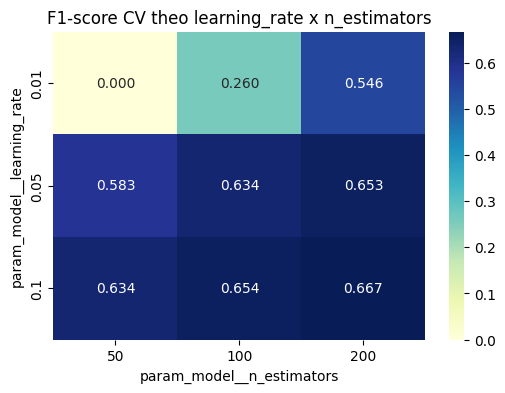

In [27]:
# Heatmap trực quan hoá lưới learning_rate x n_estimators
pivot = results.pivot(
    index="param_model__learning_rate",
    columns="param_model__n_estimators",
    values="mean_test_score"
)
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1-score CV theo learning_rate x n_estimators")
plt.show()

In [28]:
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_ada = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ))
])

### Vì sao Boosting dùng cây NÔNG còn Random Forest dùng cây SÂU?

- **Random Forest (Bagging):** mỗi cây được huấn luyện độc lập trên một mẫu bootstrap, sau đó lấy trung bình/biểu quyết để **giảm phương sai (variance)**. Muốn giảm phương sai hiệu quả, từng cây cần có độ lệch (bias) thấp → cây phải **sâu** (gần như fit hết dữ liệu của nó), vì việc lấy trung bình nhiều cây sâu, tương quan thấp sẽ tự triệt tiêu phần overfit riêng lẻ.
- **Gradient Boosting:** các cây được huấn luyện **tuần tự**, mỗi cây sau chỉ học phần sai số (residual/gradient) còn lại của các cây trước → mục tiêu là **giảm độ lệch (bias) từ từ, có kiểm soát**. Nếu mỗi cây đã sâu (độ lệch thấp), tổng nhiều cây sâu cộng dồn sẽ overfit rất nhanh. Vì vậy Boosting dùng cây **nông** (thường `max_depth` 2-4, thậm chí stump) đóng vai trò "weak learner", kết hợp với `learning_rate` nhỏ để mô hình học chậm và ổn định.

## 7. So sánh Random Forest vs Gradient Boosting vs AdaBoost

In [29]:
import time
from sklearn.metrics import average_precision_score

def fit_and_score(name, pipeline, x_train, y_train, x_test, y_test):
    start = time.time()
    pipeline.fit(x_train, y_train)
    train_time = time.time() - start

    proba = pipeline.predict_proba(x_test)[:, list(pipeline.classes_).index(">50K")]
    pr_auc = average_precision_score((y_test == ">50K").astype(int), proba)

    model = pipeline.named_steps["model"]
    n_estimators = getattr(model, "n_estimators", None)
    max_depth = getattr(model, "max_depth", None)

    return {
        "Mô hình": name,
        "PR-AUC": round(pr_auc, 4),
        "Thời gian train (s)": round(train_time, 2),
        "n_estimators": n_estimators,
        "max_depth": max_depth,
    }

compare_rows = [
    fit_and_score("Random Forest", pipeline_rf, x_train, y_train, x_test, y_test),
    fit_and_score("Gradient Boosting", pipeline_gbc_basic, x_train, y_train, x_test, y_test),
    fit_and_score("AdaBoost", pipeline_ada, x_train, y_train, x_test, y_test),
]

compare_df = pd.DataFrame(compare_rows)
compare_df

,Mô hình,PR-AUC,Thời gian train (s),n_estimators,max_depth
0,Random Forest,0.7019,0.63,100,NaN
1,Gradient Boosting,0.7634,5.93,100,3.0
2,AdaBoost,0.7333,6.67,100,NaN


*Ghi chú:* `n_estimators`/`max_depth` ở đây dùng làm đại diện cho **độ phức tạp cấu hình** của mỗi mô hình (số lượng cây và độ sâu tối đa cho phép) — cây quyết định không có khái niệm "số tham số" cố định như mô hình tuyến tính vì cấu trúc cây phụ thuộc dữ liệu.

## 8. So sánh thời gian: GradientBoosting vs HistGradientBoosting

In [30]:
pipeline_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

timing_rows = [
    fit_and_score("GradientBoosting", pipeline_gbc_basic, x_train, y_train, x_test, y_test),
    fit_and_score("HistGradientBoosting", pipeline_hgb, x_train, y_train, x_test, y_test),
]
pd.DataFrame(timing_rows)[["Mô hình", "PR-AUC", "Thời gian train (s)"]]

,Mô hình,PR-AUC,Thời gian train (s)
0,GradientBoosting,0.7634,9.31
1,HistGradientBoosting,0.7752,1.21


`HistGradientBoostingClassifier` gom giá trị đặc trưng liên tục vào các bin (histogram-based), giúp tìm điểm chia nhanh hơn nhiều so với `GradientBoostingClassifier` (vốn duyệt qua tất cả giá trị) → **thời gian train ngắn hơn đáng kể** trên tập dữ liệu cỡ vừa/lớn như adult, thường với PR-AUC tương đương.

## 9. ⚖️ Kiểm tra thiên lệch (bias) theo `sex` và `race`

Dùng mô hình Gradient Boosting cơ bản để đo **tỉ lệ dự đoán thu nhập >50K** và **Recall/Precision** theo từng nhóm giới tính và chủng tộc, nhằm phát hiện chênh lệch đối xử giữa các nhóm.

In [31]:
def bias_report(group_col):
    df_report = x_test.copy()
    df_report["y_true"] = y_test.values
    df_report["y_pred"] = pipeline_gbc_basic.predict(x_test)

    rows = []
    for group, sub in df_report.groupby(group_col):
        selection_rate = (sub["y_pred"] == ">50K").mean()
        recall = recall_score(sub["y_true"], sub["y_pred"], pos_label=">50K", zero_division=0)
        precision = precision_score(sub["y_true"], sub["y_pred"], pos_label=">50K", zero_division=0)
        rows.append({
            group_col: group,
            "Số lượng": len(sub),
            "Tỉ lệ dự đoán >50K": round(selection_rate, 3),
            "Recall": round(recall, 3),
            "Precision": round(precision, 3),
        })
    return pd.DataFrame(rows).sort_values("Tỉ lệ dự đoán >50K", ascending=False)

sex_report = bias_report("sex")
sex_report

,sex,Số lượng,Tỉ lệ dự đoán >50K,Recall,Precision
1,Male,4065,0.246,0.589,0.745
0,Female,1968,0.080,0.477,0.713


In [32]:
race_report = bias_report("race")
race_report

,race,Số lượng,Tỉ lệ dự đoán >50K,Recall,Precision
1,Asian-Pac-Islander,186,0.226,0.636,0.667
4,White,5186,0.205,0.579,0.746
3,Other,38,0.105,0.667,0.500
0,Amer-Indian-Eskimo,64,0.094,0.333,0.333
2,Black,559,0.081,0.425,0.756


*Chênh lệch lớn về "Tỉ lệ dự đoán >50K" giữa các nhóm không tự động nghĩa là mô hình "bất công" — dữ liệu census 1994 vốn phản ánh chênh lệch thu nhập thực tế theo giới tính/chủng tộc trong xã hội thời điểm đó. Tuy nhiên, nếu Recall (khả năng phát hiện đúng người thu nhập cao) chênh lệch mạnh giữa các nhóm, đó là dấu hiệu mô hình học kém hơn với một số nhóm nhất định và cần lưu ý khi triển khai thực tế.*